In [1]:
from pathlib import Path
import sys
from plyfile import PlyData
import numpy as np
import matplotlib.pyplot as plt
import torch

from autoencoder.model import Autoencoder
from eval.openclip_encoder import OpenCLIPNetwork

In [3]:
# for hypernerf data dirs
data_root = Path("data/hypernerf/chickchicken")
rgb_root = data_root / "rgb/2x"
lang_root = data_root / "clip_features"

queries = [
    "hand", "chicken"
]
neutral_corpus = [
    "object",
    "things",
    "stuff",
    "texture"
]

ae_path = Path("autoencoder/ckpt/chickchicken_clip/best_ckpt.pth")

sam_level = 3

In [10]:
pcd = PlyData.read('output/hypernerf/chickchicken/chickchicken_3/point_cloud/fine-lang_iteration_10000/point_cloud.ply')['vertex'].data

In [11]:
pos = np.stack([pcd['x'], pcd['y'], pcd['z']]).T
lf = np.stack([pcd['f_lang_0'], pcd['f_lang_1'], pcd['f_lang_2']]).T

In [12]:
lf

array([[ 0.01501376,  0.01501376,  0.01501376],
       [-0.01290365,  0.0129036 , -0.01290364],
       [-0.01389786, -0.01390503,  0.01388878],
       ...,
       [ 0.10079853, -0.16678695,  0.34462553],
       [ 0.03076062, -0.35539845,  0.22013505],
       [-0.1236087 ,  0.02889833, -0.41145864]],
      shape=(136194, 3), dtype=float32)

In [2]:
clip_base = Path("data/hypernerf/chickchicken/clip_features")
render_base = Path("output/hypernerf/chickchicken/chickchicken_3/video_lang/ours_10000/renders_npy")

In [3]:
lf_render = np.load(render_base / "00001.npy")

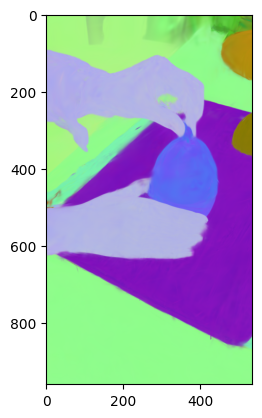

In [7]:
plt.imshow((lf_render + 1.) / 2)
plt.show()